In [1]:
!nvidia-smi

Wed Sep 30 09:04:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

print(cuda.detect())

Found 1 CUDA devices
id 0                Tesla T4                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-59788106-a3a7-d45a-3451-ab16e80326f0
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported
True


In [3]:
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

Saving cat.png to cat.png


(491, 553, 3) uint8 271523 pixels


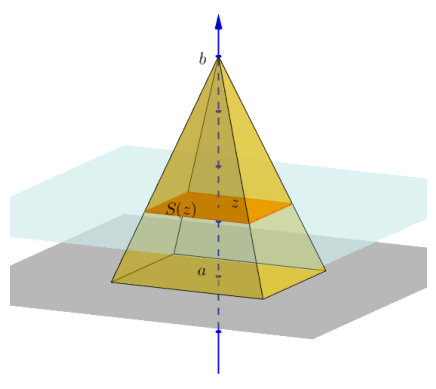

In [4]:
src = plt.imread(fname)

if src.dtype != np.uint8:
    src = (src * 255).astype(np.uint8)

if src.shape[2] == 4:
    src = src[:, :, :3]

imageHeight, imageWidth = src.shape[0], src.shape[1]
pixelCount = imageHeight * imageWidth
print(src.shape, src.dtype, pixelCount, 'pixels')

plt.imshow(src)
plt.axis('off')
plt.show()

In [10]:
flatSrc = np.ascontiguousarray(src.reshape(pixelCount, 3))
print(flatSrc.shape, flatSrc.flags['C_CONTIGUOUS'])

(271523, 3) True


In [11]:
def grayscaleCPU(src, dst):
    for i in range(src.shape[0]):
        g = (int(src[i, 0]) + int(src[i, 1]) + int(src[i, 2])) // 3
        dst[i, 0] = dst[i, 1] = dst[i, 2] = g


hostDst = np.zeros((pixelCount, 3), np.uint8)

start = time.time()
grayscaleCPU(flatSrc, hostDst)
cpuTime = time.time() - start
print('CPU: %.4f s' % cpuTime)

CPU: 0.5287 s


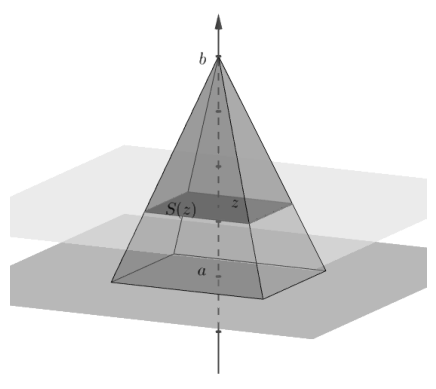

In [12]:
plt.imshow(hostDst.reshape(imageHeight, imageWidth, 3))
plt.axis('off')
plt.show()

In [ ]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx < src.shape[0]:
        g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
        dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

In [14]:
blockSize = 64
gridSize = (pixelCount + blockSize - 1) // blockSize
print(gridSize, blockSize)

devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

4243 64


In [15]:
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

start = time.time()
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
gpuTime = time.time() - start

hostDst2 = devDst.copy_to_host()
print('GPU: %.6f s' % gpuTime)
print('speedup: %.1fx' % (cpuTime / gpuTime))

GPU: 0.000298 s
speedup: 1775.4x


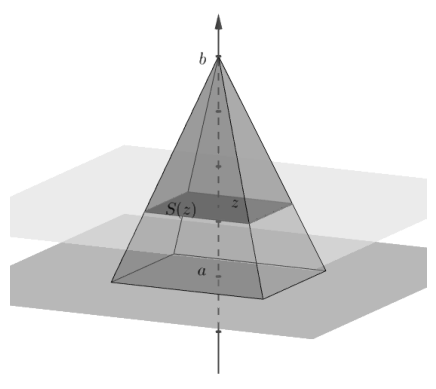

True


In [16]:
plt.imshow(hostDst2.reshape(imageHeight, imageWidth, 3))
plt.axis('off')
plt.show()

print(np.array_equal(hostDst, hostDst2))

In [17]:
plt.imsave('gray_cpu.png', hostDst.reshape(imageHeight, imageWidth, 3))
plt.imsave('gray_gpu.png', hostDst2.reshape(imageHeight, imageWidth, 3))

In [18]:
blockSizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
times = []

for bs in blockSizes:
    gs = (pixelCount + bs - 1) // bs

    grayscale[gs, bs](devSrc, devDst)   # warm up
    cuda.synchronize()

    start = time.time()
    for _ in range(20):
        grayscale[gs, bs](devSrc, devDst)
    cuda.synchronize()
    t = (time.time() - start) / 20

    times.append(t)
    print('%5d  %.6f s' % (bs, t))

    1  0.002119 s
    2  0.001063 s
    4  0.000536 s
    8  0.000273 s
   16  0.000141 s
   32  0.000075 s
   64  0.000075 s
  128  0.000075 s
  256  0.000075 s
  512  0.000079 s
 1024  0.000083 s


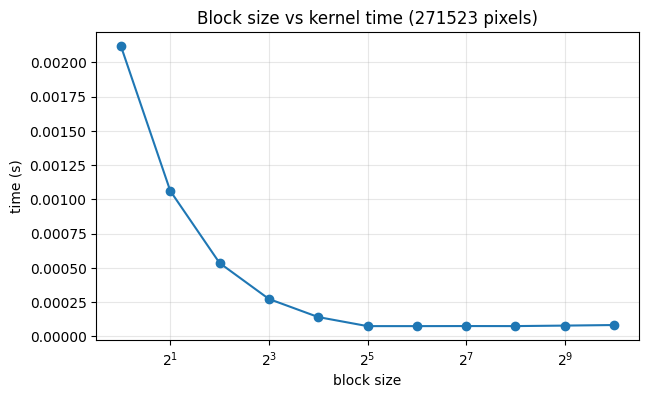

nhanh nhat: 64 -> 0.000075 s
cham nhat: 1 -> 0.002119 s


In [19]:
plt.figure(figsize=(7, 4))
plt.plot(blockSizes, times, marker='o')
plt.xscale('log', base=2)
plt.xlabel('block size')
plt.ylabel('time (s)')
plt.title('Block size vs kernel time (%d pixels)' % pixelCount)
plt.grid(True, alpha=0.3)
plt.savefig('blocksize.png', dpi=150, bbox_inches='tight')
plt.show()

best = blockSizes[int(np.argmin(times))]
print('nhanh nhat:', best, '->', '%.6f s' % min(times))
print('cham nhat:', blockSizes[int(np.argmax(times))], '->', '%.6f s' % max(times))

In [20]:
files.download('blocksize.png')
files.download('gray_gpu.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>